In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# AlphaZero — Tic-tac-toe Training

This notebook trains an AlphaZero agent on Tic-tac-toe and visualises the training progress.

**Board layout** (action indices):
```
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8
```
Player 1 = `1`, Player 2 = `-1`, Empty = `0`.

## 1. Imports

In [4]:
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tictactoe.tictactoe import TicTacToe
from model.model import ResNet
from mcts.mcts import MCTS
from train.train import self_play, train_step

## 2. Hyperparameters

In [5]:
args = {
    # Model
    "num_res_blocks": 4,
    "num_hidden": 64,

    # MCTS
    "num_searches": 100,    # simulations per move during self-play

    # Training loop
    "num_iterations": 10,   # outer iterations
    "num_self_play_games": 20,  # games per iteration
    "num_epochs": 5,        # gradient steps per iteration
    "batch_size": 64,
    "lr": 1e-3,
}

## 3. Initialise

In [6]:
game = TicTacToe()
model = ResNet(game, num_res_blocks=args["num_res_blocks"], num_hidden=args["num_hidden"])
optimizer = optim.Adam(model.parameters(), lr=args["lr"])
mcts = MCTS(game, model=model, num_searches=args["num_searches"])

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 303,342


## 4. Training loop

Each iteration:
1. **Self-play** — generate games using MCTS guided by the current model
2. **Train** — update the model on the collected examples

In [7]:
loss_history = []  # mean loss per iteration

for iteration in range(args["num_iterations"]):
    # --- Self-play ---
    examples = []
    for _ in range(args["num_self_play_games"]):
        examples += self_play(game, mcts, model)

    encoded_states = np.array([e[0] for e in examples], dtype=np.float32)
    policies       = np.array([e[1] for e in examples], dtype=np.float32)
    outcomes       = np.array([e[2] for e in examples], dtype=np.float32)

    # --- Train ---
    iteration_losses = []
    model.train()
    for _ in range(args["num_epochs"]):
        batch_size = min(args["batch_size"], len(examples))
        idx = np.random.choice(len(examples), size=batch_size, replace=False)
        batch = (encoded_states[idx], policies[idx], outcomes[idx])
        loss = train_step(model, optimizer, batch)
        iteration_losses.append(loss)

    mean_loss = np.mean(iteration_losses)
    loss_history.append(mean_loss)
    print(f"Iteration {iteration + 1:3d}/{args['num_iterations']} | "
          f"examples: {len(examples):4d} | loss: {mean_loss:.4f}")

Iteration   1/10 | examples:  135 | loss: 2.7561
Iteration   2/10 | examples:  141 | loss: 2.6729
Iteration   3/10 | examples:  139 | loss: 2.3508
Iteration   4/10 | examples:  151 | loss: 2.1722
Iteration   5/10 | examples:  142 | loss: 2.1531
Iteration   6/10 | examples:  145 | loss: 2.0876
Iteration   7/10 | examples:  138 | loss: 1.7625
Iteration   8/10 | examples:  152 | loss: 1.6261
Iteration   9/10 | examples:  152 | loss: 1.2428
Iteration  10/10 | examples:  153 | loss: 0.9991


## 5. Loss curve

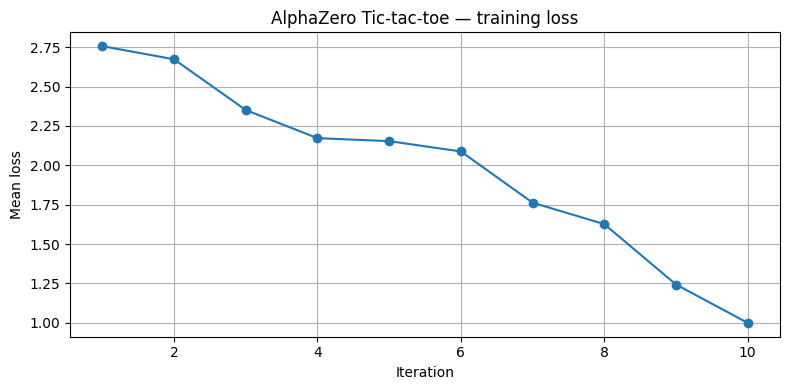

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Mean loss")
plt.title("AlphaZero Tic-tac-toe — training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Save checkpoint

In [9]:
torch.save(model.state_dict(), "model_tictactoe.pt")
print("Saved model_tictactoe.pt")

Saved model_tictactoe.pt


## 7. Play against the trained model

You play as `X` (player 1). Enter a number 0–8 to place your piece.

In [11]:
def print_board(state):
    symbols = {1: "X", -1: "O", 0: "."}
    for row in state:
        print(" | ".join(symbols[int(v)] for v in row))
    print()


model.eval()
state = game.get_initial_state()
human_player = 1
ai_player = -1
current_player = 1  # human goes first

while True:
    print_board(state)
    valid_moves = game.get_valid_moves(state)

    if current_player == human_player:
        print(f"Valid moves: {[i for i in range(game.action_size) if valid_moves[i]]}")
        action = int(input("Your move: "))
        if not valid_moves[action]:
            print("Invalid move, try again.")
            continue
    else:
        policy = mcts.search(state, ai_player)
        action = int(np.argmax(policy))
        print(f"AI plays: {action}")

    state = game.update_state(state, action, current_player)
    value, terminated = game.get_value_and_terminated(state, action)

    if terminated:
        print_board(state)
        if value == 0:
            print("Draw!")
        elif current_player == human_player:
            print("You win!")
        else:
            print("AI wins!")
        break

    current_player = game.get_opponent(current_player)

. | . | .
. | . | .
. | . | .

Valid moves: [0, 1, 2, 3, 4, 5, 6, 7, 8]
. | . | .
. | X | .
. | . | .

AI plays: 6
. | . | .
. | X | .
O | . | .

Valid moves: [0, 1, 2, 3, 5, 7, 8]
. | . | .
. | X | .
O | X | .

AI plays: 1
. | O | .
. | X | .
O | X | .

Valid moves: [0, 2, 3, 5, 8]
. | O | .
. | X | .
O | X | X

AI plays: 0
O | O | .
. | X | .
O | X | X

Valid moves: [2, 3, 5]
O | O | .
X | X | .
O | X | X

AI plays: 2
O | O | O
X | X | .
O | X | X

AI wins!
